In [46]:
import numpy as np
from sklearn.datasets import load_diabetes #sklearn needed to import dataset
from sklearn.model_selection import train_test_split

x, y = load_diabetes(return_X_y=True)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)


In [47]:
class Node:
    def __init__(self):
        self.feature   = None  # which feature are we splitting on
        self.threshold = None  # the threshold value for the split
        self.left   = None    # left child (i.e. feature <= threshold)
        self.right  = None    # right child (feature > threshold)
        self.val    = None    # store prediction value of leaf node

In [48]:
class DecisionTree:

    def __init__(self, min_samples=2, max_depth=None):
        self.min_samples = min_samples
        self.max_depth = max_depth
        self.root = None

    def build_tree(self, X, y):
        X = np.array(X)
        y = np.array(y)
        self.root = self.grow(X, y, depth=0)

    def grow(self, X, y, depth):

        node = Node()

        #if |I| \u2264 k
        if len(y) <= self.min_samples or (self.max_depth and depth >= self.max_depth):
            node.val = y.mean()
            return node

        feature, threshold = self.best_split(X, y)

        if feature is None:
            node.val = y.mean()
            return node

        node.feature = feature
        node.threshold = threshold

        I_minus = X[:, feature] < threshold
        I_plus  = X[:, feature] >= threshold

        node.left  = self.grow(X[I_minus], y[I_minus], depth + 1)
        node.right = self.grow(X[I_plus],  y[I_plus],  depth + 1)



        return node

    def best_split(self, X, y):

        best_feature = None
        best_threshold = None
        best_error = np.inf

        n_features = X.shape[1]

        # for each split dimension
        for j in range(n_features):

            # for each value
            for s in np.unique(X[:, j]):

                I_plus = y[X[:, j] >= s]
                I_minus = y[X[:, j] < s]

                if len(I_plus) == 0 or len(I_minus) == 0:
                    continue

                y_plus = I_plus.mean()
                y_minus = I_minus.mean()

                error = (
                    np.sum((I_plus - y_plus) ** 2) +
                    np.sum((I_minus - y_minus) ** 2)
                )

                if error < best_error:
                    best_error = error
                    best_feature = j
                    best_threshold = s

        return best_feature, best_threshold

    def predict(self, x):
        x = np.array(x)
        node = self.root

        while node.val is None: #while not a leaf
            if x[node.feature] <= node.threshold:
                node = node.left
            else:
                node = node.right

        return node.val

In [50]:
class RandomForest:

    def __init__(self, n_trees=10, max_depth=None, min_samples=2,
                 feature_fraction=0.7, sample_fraction=0.8):
        self.n_trees     = n_trees
        self.max_depth   = max_depth
        self.min_samples = min_samples
        self.feature_fraction   = feature_fraction
        self.sample_fraction = sample_fraction
        self.trees       = []

    def build_forest(self, X, y):
        x = np.array(X)
        y = np.array(y)

        n_samples, n_features = x.shape

        k = max(1, int(n_features * self.feature_fraction))
        s = max(1, int(n_samples * self.sample_fraction))

        self.trees = []

        for _ in range(self.n_trees):

            rows  = np.random.choice(n_samples, size=s, replace=True)
            features = np.random.choice(n_features, size=k, replace=False)

            x_sub = x[rows][:, features]
            y_sub = y[rows]

            tree = DecisionTree(max_depth=self.max_depth,
                                min_samples=self.min_samples)

            tree.build_tree(x_sub, y_sub)

            self.trees.append((tree, features))

    def predict(self, x):
        x = np.array(x)
        predictions = [tree.predict(x[features]) for tree, features in self.trees]
        return np.mean(predictions)

In [33]:
dt = DecisionTree(max_depth=5, min_samples=2)
dt.build_tree(x_train, y_train)

dt_predictions = [dt.predict(x) for x in x_test]

dt_mse = np.mean((np.array(y_test) - np.array(dt_predictions)) ** 2)
print(f"Decision Tree MSE test value: {dt_mse:.2f}")

Decision Tree MSE test value: 4737.85


In [58]:
np.random.seed(0)

rf = RandomForest(n_trees=200, max_depth=None, min_samples=2,
                  feature_fraction=0.7, sample_fraction=0.8)
rf.build_forest(x_train, y_train)

rf_predictions = [rf.predict(x) for x in x_test]

rf_mse = np.mean((np.array(y_test) - np.array(rf_predictions)) ** 2)
print(f"Random Forest MSE test: {rf_mse:.2f}")

Random Forest MSE test: 3561.49


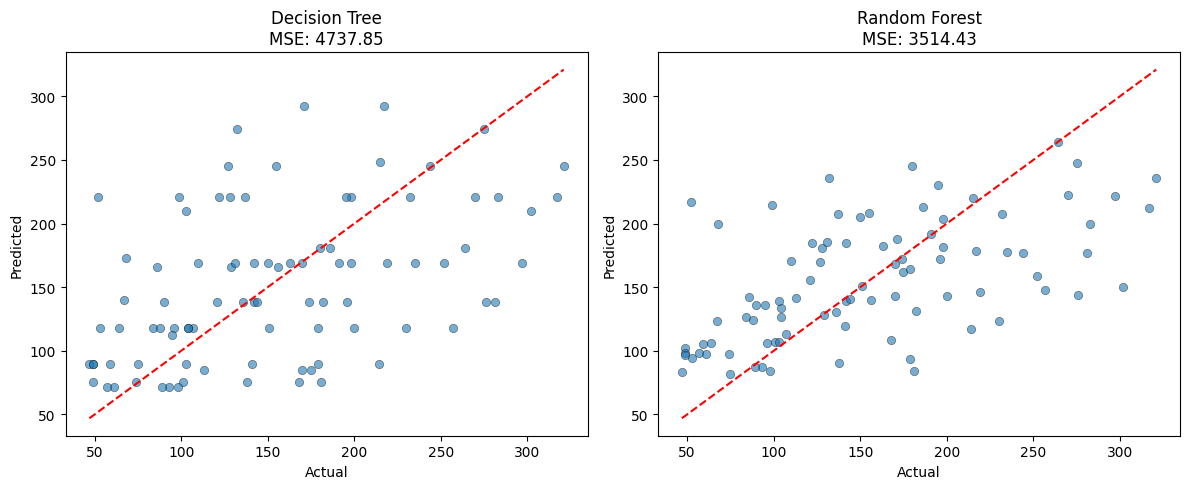

In [54]:
import matplotlib.pyplot as plt


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, predictions, title in zip(axes,
                             [dt_predictions, rf_predictions],
                             ["Decision Tree", "Random Forest"]):
    ax.scatter(y_test, predictions, alpha=0.6, edgecolors='k', linewidths=0.4)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.set_title(f"{title}\nMSE: {np.mean((y_test - np.array(predictions))**2):.2f}")

plt.tight_layout()
plt.show()